In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/elmadafri/the-wildfire-dataset/the_wildfire_dataset_2n_version/val/nofire/ashton-morris-cEn0ztKTjes-unsplash.jpg
/kaggle/input/datasets/elmadafri/the-wildfire-dataset/the_wildfire_dataset_2n_version/val/nofire/elena-mozhvilo-tvDuKySFy_o-unsplash.jpg
/kaggle/input/datasets/elmadafri/the-wildfire-dataset/the_wildfire_dataset_2n_version/val/nofire/kristaps-ungurs-TlJSzJlPRc8-unsplash.jpg
/kaggle/input/datasets/elmadafri/the-wildfire-dataset/the_wildfire_dataset_2n_version/val/nofire/nitish-meena-ytGtKR94nAI-unsplash.jpg
/kaggle/input/datasets/elmadafri/the-wildfire-dataset/the_wildfire_dataset_2n_version/val/nofire/guillaume-bourdages-VKMx4lonuLg-unsplash.jpg
/kaggle/input/datasets/elmadafri/the-wildfire-dataset/the_wildfire_dataset_2n_version/val/nofire/nathan-anderson-0mZLht43A_c-unsplash.jpg
/kaggle/input/datasets/elmadafri/the-wildfire-dataset/the_wildfire_dataset_2n_version/val/nofire/chad-madden-9HDfRHhCxME-unsplash.jpg
/kaggle/input/datasets/elmadafri/the-wil

In [2]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    print(dirname)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/elmadafri
/kaggle/input/datasets/elmadafri/the-wildfire-dataset
/kaggle/input/datasets/elmadafri/the-wildfire-dataset/the_wildfire_dataset_2n_version
/kaggle/input/datasets/elmadafri/the-wildfire-dataset/the_wildfire_dataset_2n_version/val
/kaggle/input/datasets/elmadafri/the-wildfire-dataset/the_wildfire_dataset_2n_version/val/nofire
/kaggle/input/datasets/elmadafri/the-wildfire-dataset/the_wildfire_dataset_2n_version/val/fire
/kaggle/input/datasets/elmadafri/the-wildfire-dataset/the_wildfire_dataset_2n_version/test
/kaggle/input/datasets/elmadafri/the-wildfire-dataset/the_wildfire_dataset_2n_version/test/nofire
/kaggle/input/datasets/elmadafri/the-wildfire-dataset/the_wildfire_dataset_2n_version/test/fire
/kaggle/input/datasets/elmadafri/the-wildfire-dataset/the_wildfire_dataset_2n_version/train
/kaggle/input/datasets/elmadafri/the-wildfire-dataset/the_wildfire_dataset_2n_version/train/nofire
/kaggle/input/datasets/elmadafri

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

print("Libraries Imported Successfully")

2026-06-06 18:23:29.665755: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780770209.851972      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780770209.906571      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780770210.373784      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780770210.373833      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780770210.373836      58 computation_placer.cc:177] computation placer alr

Libraries Imported Successfully


In [4]:
train_dir = "/kaggle/input/datasets/elmadafri/the-wildfire-dataset/the_wildfire_dataset_2n_version/train"

val_dir = "/kaggle/input/datasets/elmadafri/the-wildfire-dataset/the_wildfire_dataset_2n_version/val"

test_dir = "/kaggle/input/datasets/elmadafri/the-wildfire-dataset/the_wildfire_dataset_2n_version/test"

print("Dataset Paths Loaded")

Dataset Paths Loaded


In [5]:
train_dir = "/kaggle/input/datasets/elmadafri/the-wildfire-dataset/the_wildfire_dataset_2n_version/train"

val_dir = "/kaggle/input/datasets/elmadafri/the-wildfire-dataset/the_wildfire_dataset_2n_version/val"

test_dir = "/kaggle/input/datasets/elmadafri/the-wildfire-dataset/the_wildfire_dataset_2n_version/test"

print("Train:", train_dir)
print("Validation:", val_dir)
print("Test:", test_dir)

Train: /kaggle/input/datasets/elmadafri/the-wildfire-dataset/the_wildfire_dataset_2n_version/train
Validation: /kaggle/input/datasets/elmadafri/the-wildfire-dataset/the_wildfire_dataset_2n_version/val
Test: /kaggle/input/datasets/elmadafri/the-wildfire-dataset/the_wildfire_dataset_2n_version/test


In [6]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(
    rescale=1./255
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

val_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print("Dataset Loaded Successfully")

Found 1887 images belonging to 2 classes.
Found 402 images belonging to 2 classes.
Found 410 images belonging to 2 classes.
Dataset Loaded Successfully


## Dataset Visualization

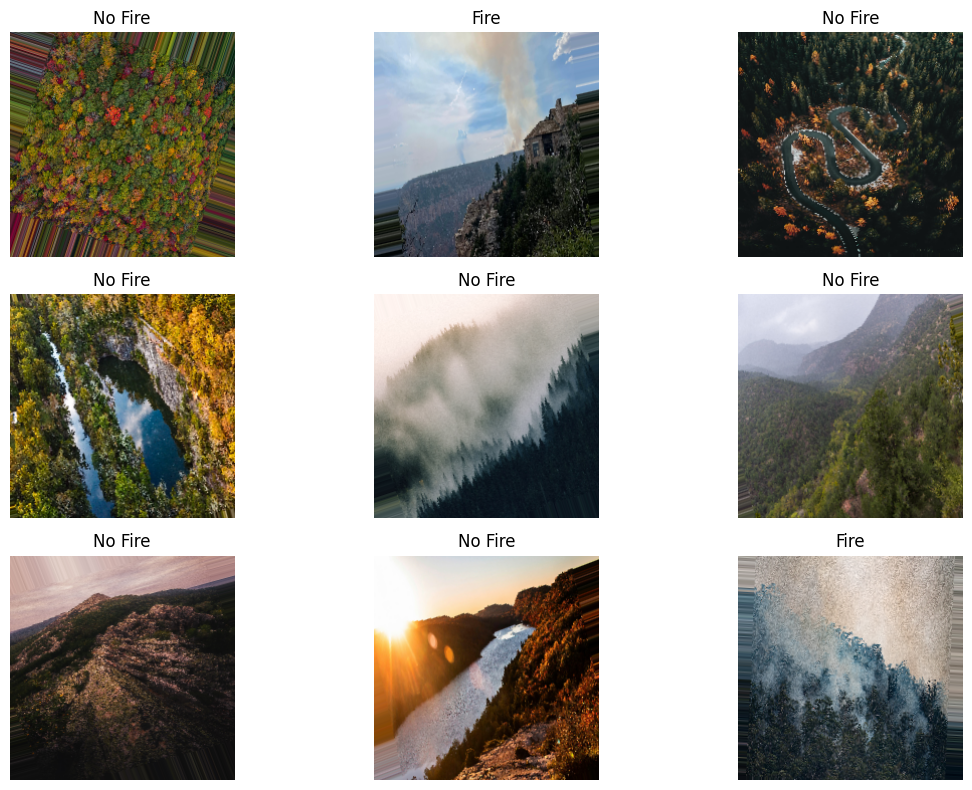

In [7]:
import matplotlib.pyplot as plt

images, labels = next(train_generator)

plt.figure(figsize=(12,8))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])

    if labels[i] == 1:
        plt.title("No Fire")
    else:
        plt.title("Fire")

    plt.axis("off")

plt.tight_layout()
plt.show()

## CNN Model Development

In [8]:
cnn_model = Sequential([

    Conv2D(32, (3,3), activation='relu',
           input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(1, activation='sigmoid')

])

cnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1780770237.593082      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

## CNN Model Training

In [9]:
history = cnn_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (89747104 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
I0000 00:00:1780770272.369060     152 service.cc:152] XLA service 0x7ac2a8006320 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780770272.369103     152 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1780770272.865622     152 cuda_dnn.cc:529] Loaded cuDNN version 91002


 1/59 ━━━━━━━━━━━━━━━━━━━━ 18:11 19s/step - accuracy: 0.5938 - loss: 0.6879

I0000 00:00:1780770277.585881     152 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


18/59 ━━━━━━━━━━━━━━━━━━━━ 5:26 8s/step - accuracy: 0.6249 - loss: 1.0292

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (104688771 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


59/59 ━━━━━━━━━━━━━━━━━━━━ 613s 10s/step - accuracy: 0.6630 - loss: 0.6472 - val_accuracy: 0.7463 - val_loss: 0.5260
Epoch 2/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 483s 8s/step - accuracy: 0.7488 - loss: 0.5015 - val_accuracy: 0.7463 - val_loss: 0.4800
Epoch 3/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 480s 8s/step - accuracy: 0.7615 - loss: 0.5004 - val_accuracy: 0.7438 - val_loss: 0.5031
Epoch 4/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 500s 8s/step - accuracy: 0.7605 - loss: 0.4871 - val_accuracy: 0.7637 - val_loss: 0.4682
Epoch 5/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 478s 8s/step - accuracy: 0.7721 - loss: 0.4742 - val_accuracy: 0.7438 - val_loss: 0.4876
Epoch 6/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 495s 8s/step - accuracy: 0.7636 - loss: 0.4911 - val_accuracy: 0.7612 - val_loss: 0.4774
Epoch 7/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 485s 8s/step - accuracy: 0.7880 - loss: 0.4619 - val_accuracy: 0.7811 - val_loss: 0.4571
Epoch 8/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 483s 8s/step - accuracy: 0.7827 - loss: 0.4674 - val_accuracy: 0.7662 - val_loss: 0

## CNN Model Evaluation

In [10]:
test_loss, test_accuracy = cnn_model.evaluate(test_generator)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

 5/13 ━━━━━━━━━━━━━━━━━━━━ 50s 6s/step - accuracy: 0.7719 - loss: 0.5243

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (96631920 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (94487082 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


 6/13 ━━━━━━━━━━━━━━━━━━━━ 54s 8s/step - accuracy: 0.7674 - loss: 0.5254

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (101859328 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


13/13 ━━━━━━━━━━━━━━━━━━━━ 118s 9s/step - accuracy: 0.8244 - loss: 0.3964
Test Accuracy: 0.8243902325630188
Test Loss: 0.3964330554008484


In [11]:
cnn_model.save("forest_fire_cnn.h5")

In [12]:
plt.savefig("accuracy_loss_curve.pdf")

<Figure size 640x480 with 0 Axes>

In [13]:
plt.savefig("confusion_matrix.pdf")

<Figure size 640x480 with 0 Axes>

# Save CNN Model

In [14]:
cnn_model.save("forest_fire_cnn.h5")

print("Model Saved Successfully")

Model Saved Successfully


# Accuracy and Loss Curves

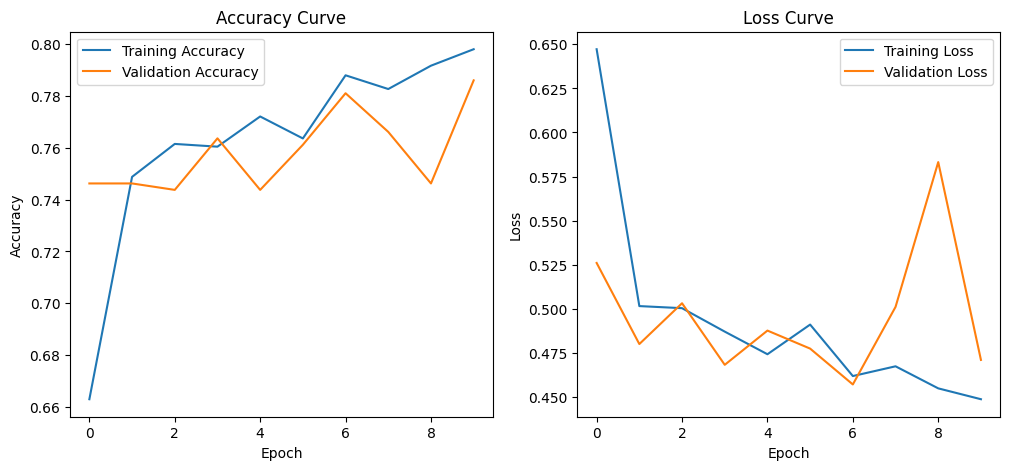

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.savefig("accuracy_loss_curve.pdf")
plt.show()

# Confusion Matrix

 5/13 ━━━━━━━━━━━━━━━━━━━━ 39s 5s/step

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (96631920 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (94487082 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


 6/13 ━━━━━━━━━━━━━━━━━━━━ 41s 6s/step

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (101859328 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


13/13 ━━━━━━━━━━━━━━━━━━━━ 103s 8s/step


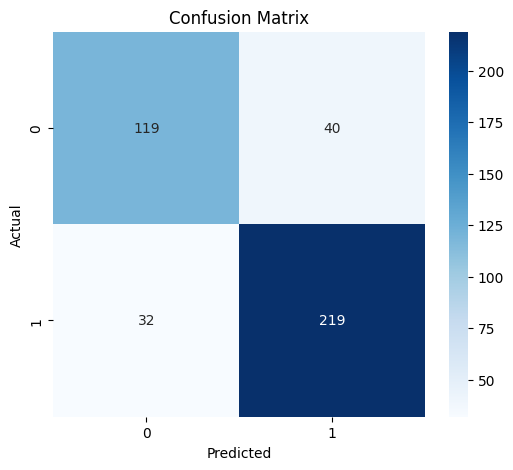

In [16]:


import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns

predictions = cnn_model.predict(test_generator)

y_pred = (predictions > 0.5).astype(int)

cm = confusion_matrix(test_generator.classes, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.savefig("confusion_matrix.pdf")
plt.show()

# Classification Report

In [17]:
from sklearn.metrics import classification_report

print(
    classification_report(
        test_generator.classes,
        y_pred,
        target_names=['Fire','No Fire']
    )
)

              precision    recall  f1-score   support

        Fire       0.79      0.75      0.77       159
     No Fire       0.85      0.87      0.86       251

    accuracy                           0.82       410
   macro avg       0.82      0.81      0.81       410
weighted avg       0.82      0.82      0.82       410



In [18]:
import os

for root, dirs, files in os.walk('/kaggle'):
    for file in files:
        if file.endswith('.h5'):
            print(os.path.join(root, file))

/kaggle/working/forest_fire_cnn.h5
